
# 04 - Model 2: SVD (Matrix Factorization)
SVD learns hidden patterns (latent factors) in user-movie interactions.
Unlike CF which compares movies directly, SVD compresses the entire
rating matrix into a compact representation capturing deep user preferences

## Why SVD?
- Handles sparsity better than Item-Based CF
- Learns latent factors representing hidden user preferences
- More scalable to large datasets
- Used by winning teams in the original Netflix Prize competition

In [ ]:
# Cell 1 - setup
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/netflix_project'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle

!pip install scikit-surprise

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

os.makedirs(f'{BASE}/models', exist_ok=True)
os.makedirs(f'{BASE}/outputs', exist_ok=True)

df = pd.read_csv(f'{BASE}/data/processed/ratings_sampled.csv')
movies = pd.read_csv(f'{BASE}/data/processed/movies.csv')

print("Setup complete!")
print(f"Ratings: {df.shape}")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.3 MB/s eta 0:00:00
Setup complete!
Ratings: (18829034, 4)


## Same Sample as Notebook 03
Using identical 1M sample with random_state=42 ensures fair comparison
between Item-Based CF and SVD models.

In [ ]:
# Cell 2 - same 1M sample as notebook 03 (ensures fair comparison)
df_model = df.sample(n=1000000, random_state=42).reset_index(drop=True)
print(f"Dataset: {df_model.shape}")
print(f"Users: {df_model['user_id'].nunique():,}")
print(f"Movies: {df_model['movie_id'].nunique():,}")

Dataset: (1000000, 4)
Users: 174,422
Movies: 15,993


## Preparing Data

In [ ]:
# Cell 3 - prepare data for Surprise
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_model[['user_id', 'movie_id', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print("Trainset size:", trainset.n_ratings)
print("Testset size:", len(testset))

Trainset size: 800000
Testset size: 200000


## Training SVD Model
n_factors=100: number of latent factors
n_epochs=20: training iterations
lr_all=0.005: learning rate
reg_all=0.02: regularization to prevent overfitting

In [ ]:
# Cell 4 - train SVD model


svd = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

svd.fit(trainset)
print("Training complete!")

Training complete!


## Evaluation

In [ ]:
# Cell 5 - evaluate
predictions = svd.test(testset)
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

print(f"\nSVD Results:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

RMSE: 1.0373
MAE:  0.8252

SVD Results:
RMSE: 1.0373
MAE:  0.8252


## Saving Predictions

In [ ]:
# Cell 6 - save predictions
preds_df = pd.DataFrame([
    {'user_id': p.uid, 'movie_id': p.iid,
     'actual': p.r_ui, 'predicted': p.est}
    for p in predictions
])
preds_df.to_csv(f'{BASE}/data/processed/svd_predictions.csv', index=False)
print("Predictions saved!")
print(preds_df.head(10))

Predictions saved!
   user_id  movie_id  actual  predicted
0  1316350     14940     3.0   3.030011
1   199832     12155     5.0   4.461502
2   267742     15646     4.0   3.721156
3   245080     15532     3.0   3.620701
4  1648946      8317     5.0   3.612159
5   468724     12338     5.0   4.043172
6   273337       483     3.0   3.453745
7   371163     16113     3.0   3.742021
8  1228560     13811     5.0   3.836294
9  1601592      5191     4.0   3.419351


## Model Comparison

In [ ]:
# Cell 7 - compare SVD vs Item-CF
itemcf_preds = pd.read_csv(f'{BASE}/data/processed/itemcf_predictions.csv')

itemcf_rmse = np.sqrt(((itemcf_preds['actual'] - itemcf_preds['predicted'])**2).mean())
itemcf_mae  = (itemcf_preds['actual'] - itemcf_preds['predicted']).abs().mean()

svd_rmse = np.sqrt(((preds_df['actual'] - preds_df['predicted'])**2).mean())
svd_mae  = (preds_df['actual'] - preds_df['predicted']).abs().mean()

comparison = pd.DataFrame({
    'Model': ['Item-Based CF', 'SVD'],
    'RMSE':  [round(itemcf_rmse, 4), round(svd_rmse, 4)],
    'MAE':   [round(itemcf_mae, 4),  round(svd_mae, 4)]
})

print(comparison.to_string(index=False))

        Model   RMSE    MAE
Item-Based CF 1.1195 0.8630
          SVD 1.0373 0.8252


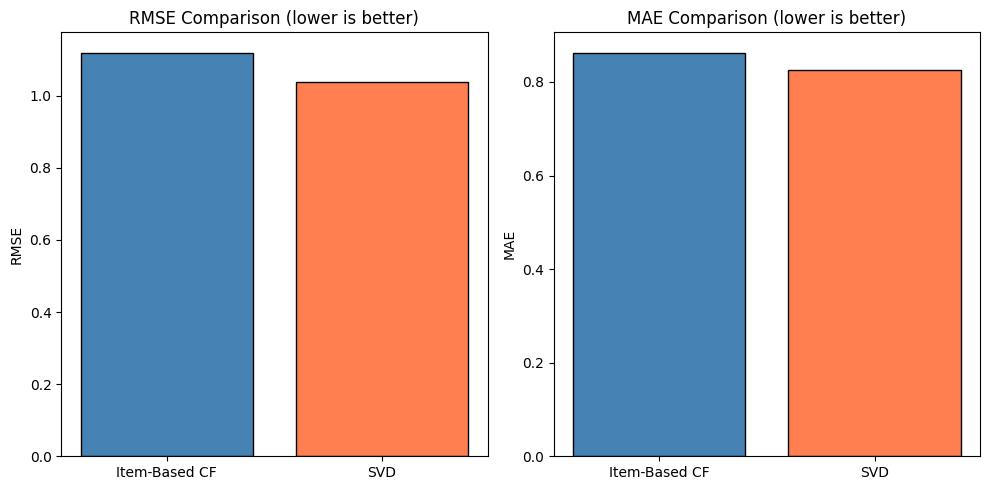

Saved!


In [ ]:
# Cell 8 - visualize comparison
x = ['Item-Based CF', 'SVD']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(x, comparison['RMSE'], color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('RMSE Comparison (lower is better)')
axes[0].set_ylabel('RMSE')

axes[1].bar(x, comparison['MAE'], color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('MAE Comparison (lower is better)')
axes[1].set_ylabel('MAE')

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/model_comparison.png')
plt.show()
print("Saved!")

## Top 10 Recommendations

In [ ]:
# Cell 9 - Top 10 recommendations using SVD
def get_top10_recommendations(user_id, model, df, movies, n=10):
    rated_movies = df[df['user_id'] == user_id]['movie_id'].tolist()
    all_movies = df['movie_id'].unique()
    unrated = [m for m in all_movies if m not in rated_movies]

    predictions = [model.predict(user_id, movie_id) for movie_id in unrated]
    predictions.sort(key=lambda x: x.est, reverse=True)
    top_n = predictions[:n]

    results = pd.DataFrame([
        {'movie_id': p.iid, 'predicted_rating': round(p.est, 2)}
        for p in top_n
    ])
    results = results.merge(movies[['movie_id', 'title']], on='movie_id')
    return results[['title', 'predicted_rating']]

# pick user with varied ratings
user_rating_std = df.groupby('user_id')['rating'].std()
varied_users = user_rating_std[user_rating_std > 1.0].index
sample_user = df[df['user_id'].isin(varied_users)]['user_id'].iloc[0]

print(f"User {sample_user} rating history:")
print(df[df['user_id'] == sample_user]['rating'].value_counts().sort_index())
print(f"\nSVD Top 10 for user {sample_user}:\n")
recs = get_top10_recommendations(sample_user, svd, df, movies)
print(recs.to_string(index=False))

User 814701 rating history:
rating
1     6
2    17
3    24
4    45
5    46
Name: count, dtype: int64

SVD Top 10 for user 814701:

                                    title  predicted_rating
                            CSI: Season 3              4.92
                          Fahrenheit 9/11              4.86
                         Samurai Champloo              4.75
                  Gilmore Girls: Season 3              4.74
                  Something the Lord Made              4.73
       Buffy the Vampire Slayer: Season 3              4.72
                               Braveheart              4.72
               Sex and the City: Season 2              4.71
The Shawshank Redemption: Special Edition              4.67
                   The Sopranos: Season 1              4.65


## Key Observations
- SVD outperforms Item-Based CF on both RMSE and MAE
- SVD produces realistic varied predictions unlike Item-CF
- SVD handles 99.4% sparsity better through latent factor learning
- Both models agree on recommendations for same user validating quality

In [ ]:
# Cell 10 - save SVD model
with open(f'{BASE}/models/svd_model.pkl', 'wb') as f:
    pickle.dump(svd, f)
print("SVD model saved!")

SVD model saved!
